##Model 4 : Conv1d + Basic Tokenizer

In [ ]:
!pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 9.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
train_df = pd.read_excel("train.xlsx")
valid_df = pd.read_excel("valid.xlsx")
test_df  = pd.read_excel("test.xlsx")

train_df.shape, valid_df.shape, test_df.shape

((5701, 2), (1222, 2), (1222, 2))

In [ ]:
from collections import Counter

MAX_VOCAB = 20000
MAX_LEN = 50

counter = Counter()

for text in train_df["Tweet"]:
    counter.update(text.lower().split())

vocab = {"<pad>": 0, "<unk>": 1}
for word, _ in counter.most_common(MAX_VOCAB - 2):
    vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)
print("VOCAB_SIZE:", VOCAB_SIZE)


VOCAB_SIZE: 17096


In [ ]:
import torch

def encode(text):
    tokens = text.lower().split()
    ids = [vocab.get(t, vocab["<unk>"]) for t in tokens][:MAX_LEN]
    if len(ids) < MAX_LEN:
        ids += [vocab["<pad>"]] * (MAX_LEN - len(ids))
    return ids

X_train = torch.tensor(
    [encode(t) for t in train_df["Tweet"]],
    dtype=torch.long
)
y_train = torch.tensor(train_df["Label"].values, dtype=torch.long)

X_valid = torch.tensor(
    [encode(t) for t in valid_df["Tweet"]],
    dtype=torch.long
)
y_valid = torch.tensor(valid_df["Label"].values, dtype=torch.long)


In [ ]:
X_train[0]


tensor([  11,  712,    5,  291,   37,    6,  217,  271, 2450,   23,    5,   46,
          27,  237, 1078,  444,    8,  217,   11,    6,  739, 3388,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0])

In [ ]:
from torch.utils.data import Dataset, DataLoader

class TweetDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 64

train_ds = TweetDataset(X_train, y_train)
valid_ds = TweetDataset(X_valid, y_valid)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=batch_size,
    shuffle=False
)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TextCNN(nn.Module):
    def __init__(
        self,
        vocab_size,
        emb_dim=100,
        num_classes=3,
        kernel_sizes=(3, 4, 5),
        num_filters=50,
        dropout=0.6
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            emb_dim,
            padding_idx=vocab["<pad>"]
        )

        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=emb_dim,
                out_channels=num_filters,
                kernel_size=k
            )
            for k in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        # x: (B, T)
        emb = self.embedding(x)           # (B, T, D)
        emb = emb.transpose(1, 2)         # (B, D, T)

        conv_outs = []
        for conv in self.convs:
            c = F.relu(conv(emb))         # (B, F, T-k+1)
            p = F.max_pool1d(c, c.size(2)).squeeze(2)
            conv_outs.append(p)

        out = torch.cat(conv_outs, dim=1)
        out = self.dropout(out)
        return self.fc(out)


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = TextCNN(
    vocab_size=len(vocab),
    emb_dim=128,
    num_classes=3,
    kernel_sizes=(3, 4, 5),
    num_filters=100,
    dropout=0.5
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)


In [ ]:
import torch
from sklearn.metrics import f1_score

num_epochs = 30

train_losses = []
val_losses = []
val_f1s = []

for epoch in range(num_epochs):

    # =====================
    # TRAIN
    # =====================
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # =====================
    # VALIDATION
    # =====================
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(y_batch.cpu())

    avg_val_loss = val_loss / len(valid_loader)
    val_losses.append(avg_val_loss)

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    val_macro_f1 = f1_score(all_labels, all_preds, average="macro")
    val_f1s.append(val_macro_f1)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Macro F1: {val_macro_f1:.4f}"
    )


Epoch [1/30] | Train Loss: 0.4979 | Val Loss: 0.8896 | Val Macro F1: 0.5199
Epoch [2/30] | Train Loss: 0.4741 | Val Loss: 0.9008 | Val Macro F1: 0.5121
Epoch [3/30] | Train Loss: 0.4257 | Val Loss: 0.8982 | Val Macro F1: 0.5370
Epoch [4/30] | Train Loss: 0.4109 | Val Loss: 0.8991 | Val Macro F1: 0.5368
Epoch [5/30] | Train Loss: 0.3842 | Val Loss: 0.9047 | Val Macro F1: 0.5411
Epoch [6/30] | Train Loss: 0.3563 | Val Loss: 0.9233 | Val Macro F1: 0.5343
Epoch [7/30] | Train Loss: 0.3324 | Val Loss: 0.9313 | Val Macro F1: 0.5352
Epoch [8/30] | Train Loss: 0.3105 | Val Loss: 0.9434 | Val Macro F1: 0.5353
Epoch [9/30] | Train Loss: 0.3021 | Val Loss: 0.9417 | Val Macro F1: 0.5366
Epoch [10/30] | Train Loss: 0.2695 | Val Loss: 0.9570 | Val Macro F1: 0.5327
Epoch [11/30] | Train Loss: 0.2559 | Val Loss: 0.9595 | Val Macro F1: 0.5474
Epoch [12/30] | Train Loss: 0.2471 | Val Loss: 0.9681 | Val Macro F1: 0.5444
Epoch [13/30] | Train Loss: 0.2402 | Val Loss: 0.9701 | Val Macro F1: 0.5510
Epoch [1

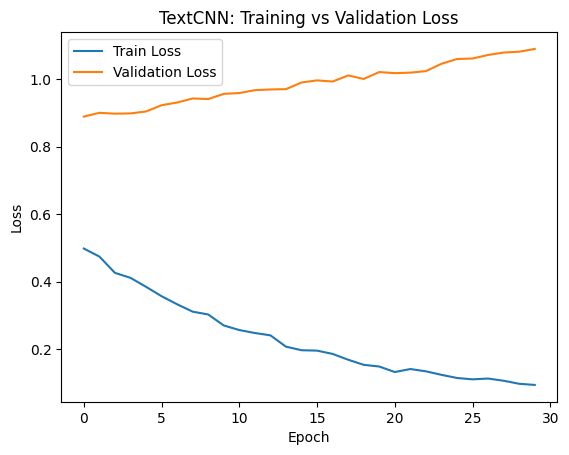

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("TextCNN: Training vs Validation Loss")
plt.show()


## MODEL 5 : Fine Tuned DistilBERT(Transformer) + DistilBERT tokenizer

In [ ]:
!pip install -q transformers datasets accelerate


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

In [ ]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
MAX_LEN = 64

def tokenize_texts(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

train_encodings = tokenize_texts(train_df["Tweet"])
valid_encodings = tokenize_texts(valid_df["Tweet"])
test_encodings  = tokenize_texts(test_df["Tweet"])


In [ ]:
class TweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


In [ ]:
train_dataset = TweetDataset(
    train_encodings,
    train_df["Label"].values
)

valid_dataset = TweetDataset(
    valid_encodings,
    valid_df["Label"].values
)

test_dataset = TweetDataset(
    test_encodings,
    test_df["Label"].values
)


In [ ]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

model.to(device)


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
EPOCHS = 4
LEARNING_RATE = 2e-5

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)


In [ ]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for batch in loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(loader)


In [ ]:
def eval_epoch(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            total_loss += loss.item()

    acc = correct / total
    return total_loss / len(loader), acc


In [ ]:
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader)
    val_loss, val_acc = eval_epoch(model, valid_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )


Epoch 1 | Train Loss: 0.8780 | Val Loss: 0.8018 | Val Acc: 0.6571
Epoch 2 | Train Loss: 0.5828 | Val Loss: 0.8027 | Val Acc: 0.6555
Epoch 3 | Train Loss: 0.3722 | Val Loss: 0.8678 | Val Acc: 0.6735
Epoch 4 | Train Loss: 0.2318 | Val Loss: 0.9342 | Val Acc: 0.6792
